# Ensemble — averaging three models (soft voting)

Notebook 08 picked **XGBoost** as the best single model. Random Forest and the Neural Network were close behind it. This notebook asks one simple question:

> **If we average the predictions of the three best models, do we get a better model than XGBoost on its own?**

**How soft voting works**

1. Each model gives every booking a probability of cancellation, for example Random Forest 0.70, XGBoost 0.60, Neural Network 0.50.
2. The ensemble's probability is the plain average: (0.70 + 0.60 + 0.50) / 3 = **0.60**.
3. As with every other model, a threshold then turns that probability into a yes/no answer.

**Why it can help.** The three models learn in different ways (many independent trees, trees built one after another, and a neural network), so they do not all make the same mistakes. Averaging can cancel some of those mistakes out.

**Why Logistic Regression and the Decision Tree are left out.** They are clearly weaker (0.647 and 0.708 PR-AUC against 0.74–0.76), and averaging in a weak model usually pulls the good ones down.

**Same rules as notebooks 03–07.** The comparison uses the training set only, on the same 5 folds. The test set is opened once, at the very end, after the decision has been made.

In [1]:
import ast
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (precision_recall_curve, average_precision_score, roc_auc_score,
                             f1_score, recall_score, precision_score, accuracy_score,
                             ConfusionMatrixDisplay)

palette = ['#2B5C8F', '#E05A47']

## 1. Load the training set

In [2]:
# agent is an ID, so it is read as text (see 02_preprocessing)
train = pd.read_csv('../data/processed/train.csv', dtype={'agent': str})
X_train, y_train = train.drop(columns=['is_canceled']), train['is_canceled']

print('train:', X_train.shape)
print(f'cancellation rate: {y_train.mean():.4f}')
print('test.csv is not loaded until section 7')

train: (67975, 25)
cancellation rate: 0.2775
test.csv is not loaded until section 7


## 2. Rebuild the three models with the settings their notebooks chose

In [3]:
categorical_cols = X_train.select_dtypes(exclude='number').columns
numeric_cols = X_train.select_dtypes(include='number').columns

def make_pipeline(estimator, needs_scaling):
    """Same preprocessing as notebooks 03-07: numbers are scaled only for the neural network."""
    preprocess = ColumnTransformer([
        ('num', StandardScaler() if needs_scaling else 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=100), categorical_cols),
    ], verbose_feature_names_out=False)
    return Pipeline([('prep', preprocess), ('model', estimator)])

def chosen_params(slug):
    """Read back the hyperparameters that model's own notebook selected."""
    row = pd.read_csv(f'../reports/results/{slug}.csv').iloc[0]
    return {k: ast.literal_eval(v) for k, v in json.loads(row['best_params']).items()}

models = {
    'Random Forest': make_pipeline(RandomForestClassifier(random_state=42, n_jobs=-1), False),
    'XGBoost': make_pipeline(XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'), False),
    'Neural Network': make_pipeline(MLPClassifier(random_state=42, max_iter=60, early_stopping=True,
                                                  n_iter_no_change=5, validation_fraction=0.1), True),
}
for name, slug in [('Random Forest', 'random_forest'), ('XGBoost', 'xgboost'),
                   ('Neural Network', 'neural_network')]:
    models[name].set_params(**chosen_params(slug))
    print(f'{name:15s}', chosen_params(slug))

Random Forest   {'model__n_estimators': 400, 'model__min_samples_leaf': 1, 'model__max_depth': 20}
XGBoost         {'model__n_estimators': 600, 'model__max_depth': 10, 'model__learning_rate': 0.05}
Neural Network  {'model__hidden_layer_sizes': (128, 64), 'model__alpha': 0.001}


Nothing is re-tuned here. Each model uses exactly the settings its own notebook picked (section 5 in notebooks 05, 06 and 07).

## 3. Out-of-fold predictions for each model

In [4]:
# the same 5 folds every model in this project was scored on
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof = pd.DataFrame({'is_canceled': y_train})
for name, model in models.items():
    start = time.time()
    oof[name] = cross_val_predict(model, X_train, y_train, cv=outer_cv, method='predict_proba')[:, 1]
    print(f'{name:15s} done in {time.time() - start:.0f} s')

# soft voting = the plain average of the three probabilities
oof['Ensemble'] = oof[list(models)].mean(axis=1)
oof.head().round(3)

Random Forest   done in 34 s


XGBoost         done in 10 s


Neural Network  done in 41 s


,is_canceled,Random Forest,XGBoost,Neural Network,Ensemble
0,0,0.121,0.057,0.013,0.064
1,0,0.023,0.002,0.001,0.009
2,0,0.543,0.834,0.453,0.610
3,0,0.382,0.369,0.348,0.367
4,0,0.437,0.230,0.619,0.429


**Out-of-fold** means every booking is scored by a model that did *not* see it during training, the same idea used for the threshold in notebooks 03–07. So each booking now has three honest probabilities, one per model, and the `Ensemble` column is their average.

In [5]:
# how similar are the three models' predictions?
oof[list(models)].corr().round(3)

,Random Forest,XGBoost,Neural Network
Random Forest,1.000,0.936,0.918
XGBoost,0.936,1.000,0.921
Neural Network,0.918,0.921,1.000


A correlation of 1.0 would mean two models give exactly the same scores, and averaging them would change nothing. Here the three models agree strongly (0.92 to 0.94) but not perfectly. So there is **a little room** for averaging to help, but not much: most of the time all three models make the same call on a booking.

## 4. Does the ensemble beat XGBoost? Fold by fold

In [6]:
# score every model on each of the 5 folds separately
fold_of_row = np.zeros(len(y_train), dtype=int)
for k, (_, val_idx) in enumerate(outer_cv.split(X_train, y_train)):
    fold_of_row[val_idx] = k

per_fold = pd.DataFrame({
    col: [average_precision_score(oof.loc[fold_of_row == k, 'is_canceled'],
                                  oof.loc[fold_of_row == k, col]) for k in range(5)]
    for col in list(models) + ['Ensemble']
})
per_fold.index = [f'fold {k + 1}' for k in range(5)]
per_fold['gain vs XGBoost'] = per_fold['Ensemble'] - per_fold['XGBoost']

pd.concat([per_fold, per_fold.agg(['mean', 'std'])]).round(4)

,Random Forest,XGBoost,Neural Network,Ensemble,gain vs XGBoost
fold 1,0.7606,0.7744,0.7551,0.7771,0.0027
fold 2,0.7525,0.7658,0.7370,0.7661,0.0003
fold 3,0.7403,0.7536,0.7367,0.7579,0.0042
fold 4,0.7595,0.7646,0.7493,0.7723,0.0077
fold 5,0.7613,0.7713,0.7525,0.7748,0.0035
mean,0.7548,0.7660,0.7461,0.7696,0.0037
std,0.0089,0.0080,0.0087,0.0078,0.0027


In [7]:
gain = per_fold['gain vs XGBoost']
noise = per_fold['XGBoost'].std()   # how much XGBoost's own score moves from fold to fold

print(f'mean gain of the ensemble over XGBoost: {gain.mean():+.4f}')
print(f'folds where the ensemble is better:     {(gain > 0).sum()} of 5')
print(f'XGBoost fold-to-fold spread (noise):    {noise:.4f}')
print('gain is bigger than the noise:', bool(gain.mean() > noise))

mean gain of the ensemble over XGBoost: +0.0037
folds where the ensemble is better:     5 of 5
XGBoost fold-to-fold spread (noise):    0.0080
gain is bigger than the noise: False


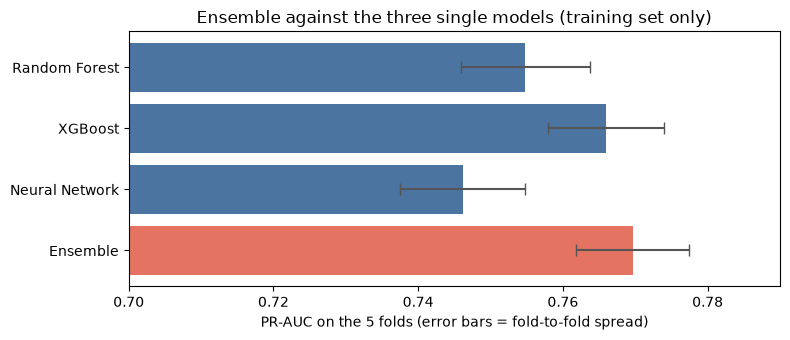

In [8]:
scores = per_fold[list(models) + ['Ensemble']]
plt.figure(figsize=(8, 3.5))
plt.barh(scores.columns[::-1], scores.mean().values[::-1], xerr=scores.std().values[::-1],
         color=[palette[1]] + [palette[0]] * 3, alpha=0.85, error_kw={'ecolor': '#555', 'capsize': 4})
plt.xlim(0.70, 0.79)
plt.xlabel('PR-AUC on the 5 folds (error bars = fold-to-fold spread)')
plt.title('Ensemble against the three single models (training set only)')
plt.tight_layout()
plt.show()

**Reading the table.** The ensemble scores **0.7696** against **0.7660** for XGBoost alone, and it is ahead in **all 5 folds**. So the gain is real, but it is very small: **+0.0037** on average.

**Is it big enough to matter?** XGBoost's own score moves by about **0.0080** from one fold to another, just from which bookings land in which fold. The gain (0.0037) is less than half of that normal wobble. We use the same rule as notebook 08: a model only replaces the winner if the gain is bigger than this noise. **The ensemble does not pass.**

(XGBoost scores 0.7660 here and 0.7612 in notebook 06. The difference is that here it reuses the settings already chosen, while notebook 06 had to search for them inside every fold. Both numbers in this table are measured the same way, so the comparison between them is fair.)

## 5. Choosing the threshold for the ensemble

In [9]:
# same method as notebooks 03-07: pick the threshold with the best F1 on out-of-fold predictions
precision, recall, thresholds = precision_recall_curve(y_train, oof['Ensemble'])
f1 = 2 * precision * recall / (precision + recall + 1e-12)
best = int(np.argmax(f1[:-1]))
threshold = float(thresholds[best])

print(f"F1 at the default 0.50 threshold: {f1_score(y_train, oof['Ensemble'] >= 0.5):.4f}")
print(f'chosen threshold: {threshold:.4f}  ->  F1 {f1[best]:.4f}, '
      f'precision {precision[best]:.4f}, recall {recall[best]:.4f}')

F1 at the default 0.50 threshold: 0.6639
chosen threshold: 0.3373  ->  F1 0.7012, precision 0.6488, recall 0.7629


The threshold is chosen on training predictions only and is fixed before the test set is opened.

## 6. Train the ensemble on the whole training set and export it

In [10]:
# VotingClassifier does exactly what section 3 did by hand: fit the three models, average their probabilities
ensemble = VotingClassifier(estimators=[('rf', models['Random Forest']),
                                        ('xgb', models['XGBoost']),
                                        ('nn', models['Neural Network'])],
                            voting='soft')
start = time.time()
ensemble.fit(X_train, y_train)
print(f'fitted on {len(X_train)} training rows in {time.time() - start:.0f} s')

Path('../models').mkdir(exist_ok=True)
joblib.dump(ensemble, '../models/ensemble.joblib', compress=3)
size_mb = Path('../models/ensemble.joblib').stat().st_size / 1e6
print(f'saved models/ensemble.joblib ({size_mb:.1f} MB)')

fitted on 67975 training rows in 18 s


saved models/ensemble.joblib (51.9 MB)


Like the single models, the saved file holds everything needed to score a new booking: `joblib.load('../models/ensemble.joblib').predict_proba(new_bookings)[:, 1]`.

## 7. The test set — opened once

Everything above used `train.csv` only. The decision in section 4 and the threshold in section 5 are already fixed. The test set now shows how the ensemble does on bookings it has never seen, next to XGBoost's result from notebook 08.

In [11]:
test = pd.read_csv('../data/processed/test.csv', dtype={'agent': str})
X_test, y_test = test.drop(columns=['is_canceled']), test['is_canceled']

test_proba = ensemble.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= threshold).astype(int)

xgb_test = pd.read_csv('../reports/results/final_model.csv').iloc[0]
comparison = pd.DataFrame([
    {'model': 'XGBoost (notebook 08)', 'threshold': xgb_test['threshold'],
     'pr_auc': xgb_test['test_pr_auc'], 'roc_auc': xgb_test['test_roc_auc'], 'f1': xgb_test['test_f1'],
     'recall': xgb_test['test_recall'], 'precision': xgb_test['test_precision'],
     'accuracy': xgb_test['test_accuracy']},
    {'model': 'Ensemble (RF + XGB + NN)', 'threshold': threshold,
     'pr_auc': average_precision_score(y_test, test_proba), 'roc_auc': roc_auc_score(y_test, test_proba),
     'f1': f1_score(y_test, test_pred), 'recall': recall_score(y_test, test_pred),
     'precision': precision_score(y_test, test_pred), 'accuracy': accuracy_score(y_test, test_pred)},
]).set_index('model')
comparison.round(4)

,threshold,pr_auc,roc_auc,f1,recall,precision,accuracy
model,,,,,,,
XGBoost (notebook 08),0.3352,0.7698,0.8924,0.7019,0.7692,0.6454,0.8187
Ensemble (RF + XGB + NN),0.3373,0.7694,0.8926,0.7019,0.7680,0.6463,0.8190


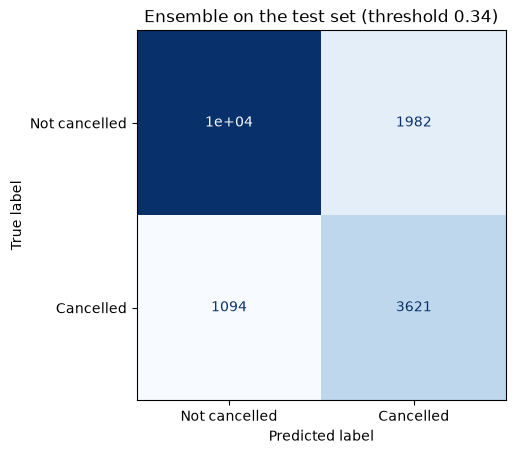

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=['Not cancelled', 'Cancelled'],
                                        cmap='Blues', colorbar=False)
plt.title(f'Ensemble on the test set (threshold {threshold:.2f})')
plt.show()

On the test set the two are **practically identical**: PR-AUC 0.7694 against 0.7698, the same F1 (0.7019), and recall, precision and accuracy all within 0.002 of each other. The test set confirms what section 4 said: averaging three models buys nothing that XGBoost does not already give on its own.

## 8. Save the result

In [13]:
row = {
    'model': 'Ensemble (RF + XGB + NN, soft voting)',
    'cv_pr_auc_mean': per_fold['Ensemble'].mean(),
    'cv_pr_auc_std': per_fold['Ensemble'].std(),
    'xgboost_cv_pr_auc_mean': per_fold['XGBoost'].mean(),
    'mean_gain_vs_xgboost': gain.mean(),
    'folds_better_than_xgboost': int((gain > 0).sum()),
    'gain_beats_noise': bool(gain.mean() > noise),
    'threshold': threshold,
    **{f'test_{k}': v for k, v in comparison.loc['Ensemble (RF + XGB + NN)'].drop('threshold').items()},
}
pd.DataFrame([row]).round(4).to_csv('../reports/results/ensemble.csv', index=False)
pd.DataFrame([row]).round(4).T

,0
model,"Ensemble (RF + XGB + NN, soft voting)"
cv_pr_auc_mean,0.7696
cv_pr_auc_std,0.0078
xgboost_cv_pr_auc_mean,0.766
mean_gain_vs_xgboost,0.0037
folds_better_than_xgboost,5
gain_beats_noise,False
threshold,0.3373
test_pr_auc,0.7694
test_roc_auc,0.8926


## Conclusion

**We keep XGBoost as the final model.** The ensemble was tried and recorded, but not adopted.

| | XGBoost alone | Ensemble (RF + XGB + NN) |
| --- | ---: | ---: |
| PR-AUC, 5 folds (training set) | 0.7660 | 0.7696 |
| PR-AUC, test set | 0.7698 | 0.7694 |
| F1, test set | 0.7019 | 0.7019 |
| Model file size | 3 MB | 52 MB |
| Models to train and explain | 1 | 3 |

1. **The gain is too small.** +0.0037 PR-AUC on the training folds, which is under the 0.0080 fold-to-fold noise. On the test set there is no gain at all.
2. **The models already agree.** Their predictions are 92–94% correlated, so averaging has little to correct.
3. **Simpler is better when the scores are equal.** One model is faster, 17 times smaller, and easier to explain to a hotel manager than three averaged models.

This fits the rest of the project. Every model, feature and setting we tried lands at about **0.76–0.77 PR-AUC**. That ceiling comes from the data, which is what is known when the booking is made, and not from the choice of model. Combining models does not get past it either.